# Model development

In [2]:
import pandas as pd 

df = pd.read_csv("taxi_cleaned_training_data.csv")
df.head()

,Trip_Distance_km,Trip_Duration_Minutes,Time_of_Day,Passenger_Count,Trip_Price
0,19.35,53.82,Morning,3.0,36.2624
1,36.87,37.27,Evening,1.0,52.9032
2,25.87,22.64,Evening,3.0,15.6180
3,8.64,89.33,Afternoon,2.0,60.2028
4,43.44,61.57,Evening,3.0,101.1216


In [3]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 716 entries, 0 to 715
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       716 non-null    float64
 1   Trip_Duration_Minutes  716 non-null    float64
 2   Time_of_Day            716 non-null    object 
 3   Passenger_Count        716 non-null    float64
 4   Trip_Price             716 non-null    float64
dtypes: float64(4), object(1)
memory usage: 28.1+ KB


Trip_Distance_km         0
Trip_Duration_Minutes    0
Time_of_Day              0
Passenger_Count          0
Trip_Price               0
dtype: int64

## Sckit learn steps

Divide into X and y
- X = what the model can know
- y = what the model get's to predict

In [4]:
X, y = df.drop(columns="Trip_Price", axis=1), df["Trip_Price"]
X.head(2)

,Trip_Distance_km,Trip_Duration_Minutes,Time_of_Day,Passenger_Count
0,19.35,53.82,Morning,3.0
1,36.87,37.27,Evening,1.0


In [5]:
y.head(2)

0    36.2624
1    52.9032
Name: Trip_Price, dtype: float64

## Train | test split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.33, random_state=42
)

## Dummy Encoding
- Categorical features -> represent with 1 and 0
- Categorical feature: Time_of_Day

In [7]:
X_train = pd.get_dummies(X_train, drop_first=True).astype(int)
X_test = pd.get_dummies(X_test, drop_first=True).astype(int)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

## Model Training 


### Scale dataset
- min-max also called normalization
- feature standardization

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

scaled_X_train.shape, scaled_X_test.shape

((479, 6), (237, 6))

In [9]:
scaled_X_train.min(), scaled_X_train.max()

(np.float64(0.0), np.float64(1.0))

In [10]:
scaled_X_test.min(), scaled_X_test.max()

(np.float64(0.0), np.float64(1.0))

## Linear Regression model

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model = LinearRegression()
model.fit(scaled_X_train, y_train)

model.intercept_, model.coef_
y_pred = model.predict(scaled_X_test)

mae_lr = mean_absolute_error(y_test, y_pred)
mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)

mae_lr, mse_lr, rmse_lr


(11.6323864190687, 207.87269298443132, np.float64(14.417790849656244))

## KNN model

In [12]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model = KNeighborsRegressor(n_neighbors=5)
model.fit(scaled_X_train, y_train)

y_pred = model.predict(scaled_X_test)

mae_knn = mean_absolute_error(y_test, y_pred)
mse_knn = mean_squared_error(y_test, y_pred)
rmse_knn = np.sqrt(mse_knn)

mae_knn, mse_knn, rmse_knn

(13.314788860759494, 271.83999304781435, np.float64(16.487570865588854))

## Random Forest model

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

clf = RandomForestRegressor()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred)
mse_rf = mean_squared_error(y_test,y_pred)
rmse_rf = np.sqrt(mse_rf)

mae_rf, mse_rf, rmse_rf

(12.596479877637126, 265.9342400649304, np.float64(16.30749030552925))

## Comparisson of all models

In [14]:
results = {}

results["LinearRegression"] = {
    "MAE": mae_lr,
    "RMSE": rmse_lr
}

results["KNN"] = {
    "MAE": mae_knn,
    "RMSE": rmse_knn
}

results["RandomForest"] = {
    "MAE": mae_rf,
    "RMSE": rmse_rf
}

results

{'LinearRegression': {'MAE': 11.6323864190687,
  'RMSE': np.float64(14.417790849656244)},
 'KNN': {'MAE': 13.314788860759494, 'RMSE': np.float64(16.487570865588854)},
 'RandomForest': {'MAE': 12.596479877637126,
  'RMSE': np.float64(16.30749030552925)}}

<function matplotlib.pyplot.show(close=None, block=None)>

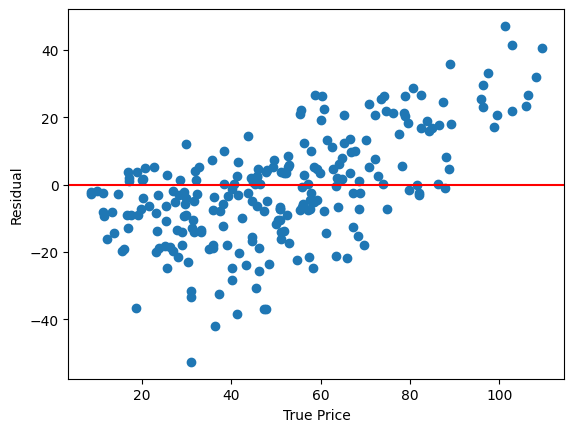

In [15]:
import matplotlib.pyplot as plt
residuals = y_test - y_pred 

plt.scatter(y_test, residuals)
plt.axhline(0, color="red")
plt.xlabel("True Price")
plt.ylabel("Residual")
plt.show

## Conclussion

After testing serveral regression models according to the data science workflow, linear regression showed the best results according to both MAE and RMSE. This indicates that the relationship in the data are largely linear and the model was therefore selected for further use.

## Final traning for production

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

numeric_features = [
    "Trip_Distance_km",
    "Trip_Duration_Minutes",
    "Passenger_Count",
]

categorical_features = [
    "Time_of_Day"
    ]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", MinMaxScaler(), numeric_features),
        ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

X, y = df[numeric_features + categorical_features], df["Trip_Price"]

final_model.fit(X,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [24]:
import joblib 

joblib.dump(final_model, "taxi_price_model.joblib")

['taxi_price_model.joblib']